In [160]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from typing import TypedDict


In [161]:
load_dotenv()

True

In [162]:
class BlogState(TypedDict):
    title:str
    outline:str
    final_blog:str

In [163]:
llm=HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="conversational",
)
chat_model = ChatHuggingFace(llm=llm)


In [164]:
graph=StateGraph(BlogState)

In [165]:
def outline(state:BlogState)->BlogState:
    title=state["title"]
    prompt=f"Write the outline for a blog post with the title: {title}"
    result=chat_model.invoke(prompt).content
    state["outline"]=result
    return state
def blog_gen(state:BlogState)->BlogState:
    outline=state["outline"]
    prompt=f"Write a blog post based on the following outline: {outline}"
    result=chat_model.invoke(prompt).content
    state["final_blog"]=result
    return state


In [166]:
graph.add_node("OUTLINE_GEN",outline)
graph.add_node("Blog_gen",blog_gen)

In [167]:
graph.add_edge(START,"OUTLINE_GEN")
graph.add_edge("OUTLINE_GEN","Blog_gen")
graph.add_edge("Blog_gen",END)

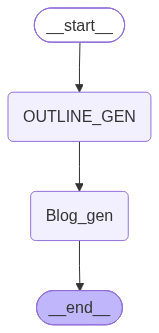

In [168]:
graph.compile()

In [169]:
workflow=graph.compile()

In [170]:
input_state={"title":"Harry Potter and the Philosopher's Stone"}

In [171]:
final_state=workflow.invoke(input_state)

In [173]:
final_state["final_blog"]

'**The Magic of Harry Potter: Unpacking the Themes and Charms of "Harry Potter and the Philosopher\'s Stone"**\n\nJ.K. Rowling\'s beloved novel, "Harry Potter and the Philosopher\'s Stone," has captivated readers of all ages since its release in 1997. This enchanting tale of a young boy who discovers he\'s a wizard has become a cultural phenomenon, inspiring a devoted fan base and spawning a successful franchise. But what is it about this book that has made it a timeless classic? In this blog post, we\'ll delve into the magical world of Hogwarts, explore the relatable protagonist at its heart, and examine the themes of friendship, loyalty, and the struggle between good and evil.\n\n**The Magic of Hogwarts**\n\nThe wizarding world that Rowling creates is nothing short of breathtaking. Hogwarts School of Witchcraft and Wizardry is a place of wonder, where magic is real and anything is possible. From the moving staircases to the ghosts that inhabit the castle, the unique features of Hogwa